In [33]:
# general
import numpy as np
from numpy.random import PCG64, SeedSequence
import pandas as pd
import verde as vd
import harmonica as hm
from scipy import interpolate
import xarray as xr
import cmocean
from cmcrameri import cm
import geopandas as gpd
from skgstat import models
import gstatsim as gsm

# plotting
import matplotlib.pyplot as plt
from matplotlib.gridspec import GridSpec, GridSpecFromSubplotSpec
from matplotlib import animation

# io
from tqdm.auto import tqdm
import os
from pathlib import Path
import time

import sys

sys.path.append('./src')
from preprocessing import *
from block_update import *
from bouguer import *
from diagnostics import *
from rfgen import *
from utilities import *
from postprocessing import *
from gstatsim_custom import *
from gaussnewton import *

In [2]:
ds = xr.open_dataarray(Path('iceshelves/abbot/results_gn/ensemble_geoid_500.nc'))
ds

<xarray.DataArray (seed_id: 200, y: 1291, x: 691)>
[178416200 values with dtype=float64]
Coordinates:
  * seed_id  (seed_id) int64 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198 199
  * y        (y) int32 147500 147000 146500 146000 ... -496500 -497000 -497500
  * x        (x) int32 -2047500 -2047000 -2046500 ... -1703500 -1703000 -1702500

In [4]:
hub = np.load(Path('iceshelves/abbot/hubs/hub_100795_192.npy'))
hub.shape

(1291, 691)

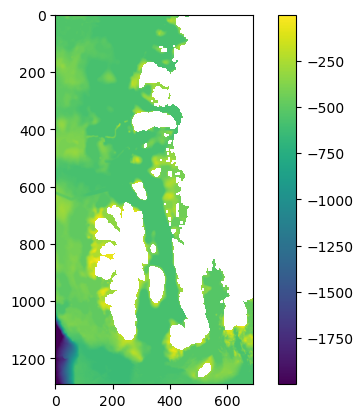

In [5]:
plt.imshow(hub)
plt.colorbar()
plt.show()

In [22]:
base_path = Path('iceshelves/abbot')
glob.glob(str(base_path/'hubs/*.npy'))

['iceshelves/abbot/hubs/hub_128105_12.npy',
 'iceshelves/abbot/hubs/hub_297855_125.npy',
 'iceshelves/abbot/hubs/hub_542188_166.npy',
 'iceshelves/abbot/hubs/hub_116742_34.npy',
 'iceshelves/abbot/hubs/hub_277721_26.npy',
 'iceshelves/abbot/hubs/hub_842002_7.npy',
 'iceshelves/abbot/hubs/hub_297915_39.npy',
 'iceshelves/abbot/hubs/hub_195808_56.npy',
 'iceshelves/abbot/hubs/hub_346126_13.npy',
 'iceshelves/abbot/hubs/hub_232309_134.npy',
 'iceshelves/abbot/hubs/hub_315470_4.npy',
 'iceshelves/abbot/hubs/hub_255679_160.npy',
 'iceshelves/abbot/hubs/hub_291409_63.npy',
 'iceshelves/abbot/hubs/hub_312610_88.npy',
 'iceshelves/abbot/hubs/hub_227638_121.npy',
 'iceshelves/abbot/hubs/hub_203669_61.npy',
 'iceshelves/abbot/hubs/hub_985802_185.npy',
 'iceshelves/abbot/hubs/hub_248484_78.npy',
 'iceshelves/abbot/hubs/hub_213942_186.npy',
 'iceshelves/abbot/hubs/hub_250024_126.npy',
 'iceshelves/abbot/hubs/hub_489072_21.npy',
 'iceshelves/abbot/hubs/hub_124271_198.npy',
 'iceshelves/abbot/hubs/h

In [28]:
fname = fnames[0]
fname

'iceshelves/abbot/hubs/hub_128105_12.npy'

In [31]:
fname.split('/')[-1][11:-4]

'12'

In [32]:
import glob
# fnames = glob.glob('iceshelves/abbot/hubs/*.npy')
base_path = Path('iceshelves/abbot')
fnames = glob.glob(str(base_path/'hubs/*.npy'))

hubs = np.empty((1, *ds.values.shape)).squeeze()

# for i, fname in enumerate(fnames):
#     hubs[i,...] = np.load(fname)

for fname in fnames:
    seed_id = int(fname.split('/')[-1][11:-4])
    
    hubs[seed_id,...] = np.load(fname)

In [25]:
hubs.shape

(200, 1291, 691)

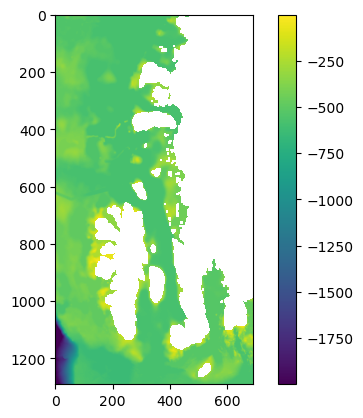

In [26]:
plt.imshow(np.mean(hubs, axis=0))
plt.colorbar()
plt.show()

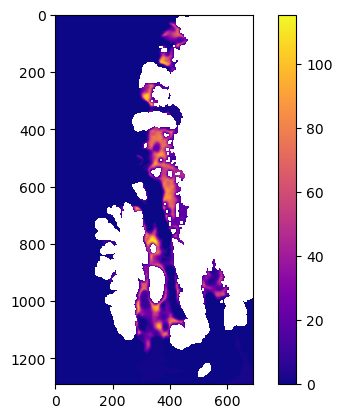

In [27]:
plt.imshow(np.std(hubs, axis=0), cmap='plasma')
plt.colorbar()
plt.show()

In [14]:
test = fnames[0]
test

'iceshelves/abbot/hubs/hub_128105_12.npy'

In [15]:
test.find('.')

35

In [17]:
test[33:test.find('.')]

'12'

In [19]:
ii = np.arange(0, 200).astype(int)

In [23]:
for fname in fnames:
    seed_id = int(fname[33:fname.find('.')])
    
    hubs[seed_id,...] = np.load(fname)

In [3]:
for entry in os.scandir('iceshelves'):
    hub_i = xr.load_dataset(Path(entry.name)/'hubs_up.nc')
    plt.imshow(hub_i.mean(dim='i'))
    plt.show()

FileNotFoundError: [Errno 2] No such file or directory: '/blue/emackie/michael.field/antarctic_iceshelves/totten/hubs_up.nc'

In [ ]:
merged_hubs(1)

In [ ]:
grid = xr.open_dataset(Path('D:/bedmachine/BedMachineAntarctica-v3.nc'))
xx_bm, yy_bm = np.meshgrid(grid.x, grid.y)

msks = np.full(xx_bm.shape, False)

water_msk = (grid.mask.values==0) | (grid.mask.values==3)

bed = grid.bed.values
min_bed = -2000
max_bed = bed[water_msk].max()
vert_res = 1

ensembles = []
ensemble_dict = {}

for i, entry in enumerate(os.scandir('iceshelves')):
    if entry.name.startswith('.')==False:
        with os.scandir(entry.path) as iceshelf_files:
            for iceshelf_file in iceshelf_files:
                if iceshelf_file.name.endswith('.nc'):
                    dataset_path = iceshelf_file.path
        ds_i = xr.open_dataarray(Path(entry.path)/'results_gn/ensemble_geoid_500.nc')
        ensembles.append(ds_i)
        ensemble_dict[entry.name] = ds_i

mask_dict = {}

i = 0
merged_i = np.full(grid.bed.shape, np.nan)

for name in ensemble_dict.keys():
    ds_j = ensemble_dict[name]
    
    xx_j, yy_j = np.meshgrid(ds_j.x, ds_j.y)
    xmin = np.min(xx_j)
    xmax = np.max(xx_j)
    ymin = np.min(yy_j)
    ymax = np.max(yy_j)
    msk_j = (xx_bm > xmin) & (xx_bm < xmax) & (yy_bm > ymin) & (yy_bm < ymax)
    msks += msk_j

    mask_dict[name] = msk_j

    bed_j = ds_j.sel(i=i).values
    kn = vd.KNeighbors(k=1)
    kn.fit((xx_j, yy_j), bed_j)
    preds_j = kn.predict((xx_bm[msk_j], yy_bm[msk_j]))

    merged_i = np.where(msk_j, emplace_data(msk_j, preds_j), merged_i)
merged_i = np.where((msks==True) & (grid.mask.values==3), merged_i, grid.bed.values)
merged_i = merged_i.astype(np.float32)
    
# np.save(Path(f'results/merged_maps/merged_map_{i}.npy'), merged_i)


In [ ]:
mask_dict

In [ ]:
plt.imshow(merged_i[2000:3000,6000:7000])
plt.colorbar()
plt.show()

In [ ]:
plt.imshow(merged_i-grid.bed.values)
plt.colorbar()
plt.show()

In [ ]:
hubs_i = hub_elevations(grid, merged_i, water_msk, min_bed, max_bed, vert_res, save_connects=False)

In [ ]:
plt.imshow(hubs_i)
plt.show()

In [ ]:
for name in mask_dict.keys():
    msk = mask_dict[name]
    hubs_msk = hubs_i[msk]

    ni = (np.count_nonzero(msk, axis=1) > 0).sum()
    nj = (np.count_nonzero(msk, axis=0) > 0).sum()

    hubs_msk = hubs_msk.reshape((ni,nj))

    plt.imshow(hubs_msk, vmin=-1000)
    plt.colorbar()
    plt.show()

    save_path = Path(f'iceshelves/{name}/hubs')
    save_path.mkdir(parents=True, exist_ok=True)
    np.save(save_path/f'hub_{i}.npy', hubs_msk)

In [ ]:
plt.imshow(msk)

In [ ]:
(np.count_nonzero(msk, axis=0) > 0).sum()

In [ ]:
(np.count_nonzero(msk, axis=1) > 0).sum()

In [ ]:
os.scandir(Path('../iceshelves'))

In [8]:
ds = xr.open_dataarray(Path('iceshelves/george/results_gn/ensemble_geoid_500.nc'))
ds

<xarray.DataArray (i: 200, y: 1291, x: 1091)>
[281696200 values with dtype=float64]
Coordinates:
  * i        (i) int64 0 1 2 3 4 5 6 7 8 ... 191 192 193 194 195 196 197 198 199
  * y        (y) int32 897500 897000 896500 896000 ... 253500 253000 252500
  * x        (x) int32 -2197500 -2197000 -2196500 ... -1653500 -1653000 -1652500

In [4]:
hub0 = np.load(Path('iceshelves/george/hubs/hub_199.npy'))

hubs = np.empty((200,*hub0.shape))
hubs.shape

(200, 1291, 1091)

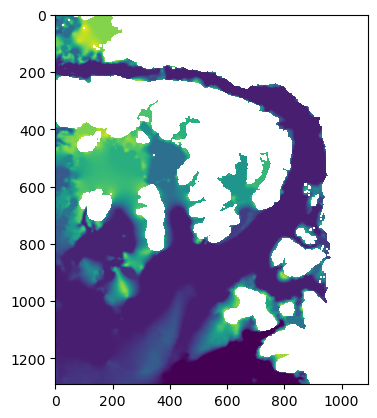

In [5]:
plt.imshow(hub0)
plt.show()

In [2]:
count = 0
seeds = []
with os.scandir(Path('iceshelves/pineisland/hubs')) as entries:
    for entry in entries:
        idx = entry.name.find('.')
        seeds.append(int(entry.name[4:idx]))
        
seeds[:5]

[152, 127, 123, 150, 122]

In [3]:
for i in range(200):
    if i not in seeds:
        print(i)

In [5]:
with os.scandir(Path('iceshelves/george/hubs')) as entries:
    for i, entry in enumerate(entries):
        hubs_i = np.load(entry.path)
        # print(i, '/t', entry.name, '/t', np.count_nonzero(hubs_i))
        # plt.imshow(hubs_i)
        # plt.show()
        hubs[i,...] = hubs_i

In [ ]:
hub_tmp = np.load(Path('iceshelves/george/hubs/hub_22.npy'))
hub_tmp

In [ ]:
plt.imshow(hub_tmp)
plt.show()

In [ ]:
import matplotlib.pyplot as plt

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
from IPython import display
import time

# Create a basic figure
fig, ax = plt.subplots()

for i in range(200):
    # Clear axes and plot new data
    ax.cla()
    ax.imshow(hubs[i,...])
    ax.set_title(f"Iteration {i}")
    
    # Update the display
    display.display(plt.gcf())
    display.clear_output(wait=True)
    time.sleep(0.5)

In [ ]:
plt.imshow(hubs[-1,...])
plt.colorbar()
plt.show()

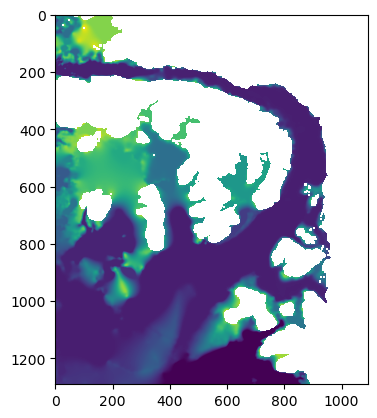

In [6]:
plt.imshow(np.mean(hubs, axis=0))
plt.show()

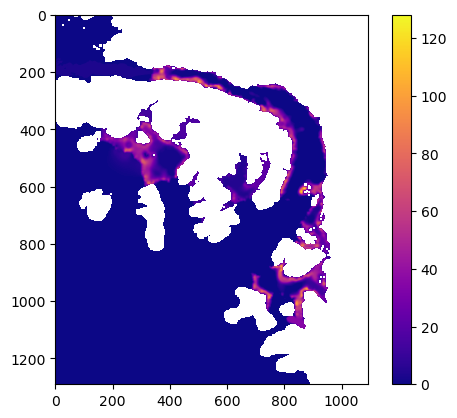

In [7]:
plt.imshow(np.std(hubs, axis=0), cmap='plasma')
plt.colorbar()
plt.show()

In [ ]:
for i in range(200):
    print(i, '/t', np.count_nonzero(hubs[i,...]))

In [13]:
for entry in os.scandir('iceshelves'):
    # for entry2 in os.scandir(entry.path):
    #     if entry2.name.endswith('.nc'):
    #         dataset_path = entry2.path
    ds_i = xr.open_dataarray(Path(entry.path)/'results_gn/ensemble_geoid_500.nc')
    hubs = np.empty((1, *ds_i.values.shape)).squeeze()
    for i in range(200):
        hubs[i,...] = np.load(Path(entry.path)/f'hubs/hub_{i}.npy')
    da = xr.DataArray(hubs, coords = {'seed_id' : np.arange(hubs.shape[0]), 'y' : ds_i.y.values, 'x' : ds_i.x.values})
    da.to_netcdf(Path(entry.path)/'hubs_up.nc')

In [15]:
hubs = xr.open_dataarray(Path('iceshelves/abbot/hubs_up.nc'))
hubs

<xarray.DataArray (seed_id: 200, y: 1291, x: 691)>
[178416200 values with dtype=float64]
Coordinates:
  * seed_id  (seed_id) int64 0 1 2 3 4 5 6 7 ... 192 193 194 195 196 197 198 199
  * y        (y) int32 147500 147000 146500 146000 ... -496500 -497000 -497500
  * x        (x) int32 -2047500 -2047000 -2046500 ... -1703500 -1703000 -1702500

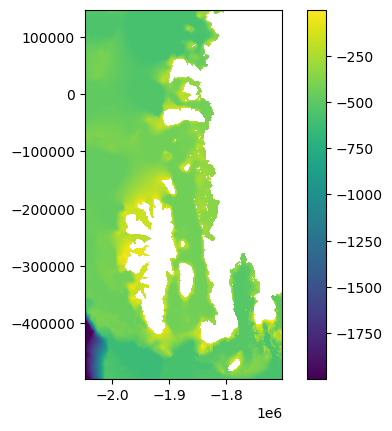

In [16]:
plt.pcolormesh(hubs.x, hubs.y, hubs.mean(dim='seed_id'))
plt.axis('scaled')
plt.colorbar()
plt.show()

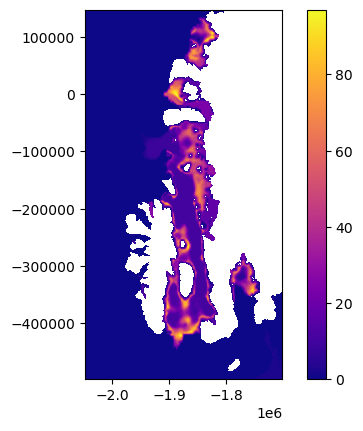

In [17]:
plt.pcolormesh(hubs.x, hubs.y, hubs.std(dim='seed_id'), cmap='plasma')
plt.axis('scaled')
plt.colorbar()
plt.show()

In [20]:
import pandas as pd

from preprocessing import *
from block_update import *
from bouguer import *
from diagnostics import *
from rfgen import *
from utilities import *
from postprocessing import *
from gstatsim_custom import *
from gaussnewton import *

In [4]:
beds, losses, targets = get_beds(Path('iceshelves/abbot/results_gn'))

In [5]:
beds.shape

(200, 130, 70)

In [7]:
targets.shape

(200, 3551)

In [10]:
ds = xr.open_dataset(Path('iceshelves/abbot/abbot.nc'))
grav = pd.read_csv(Path('iceshelves/abbot/abbot_grav.csv'))

In [18]:
grav

,x,y,height,faa,inv_msk,inv_pad,stdev
0,-2047500.0,-497500.0,1500,6.513833,False,False,15.263261
1,-2042500.0,-497500.0,1500,12.578091,False,False,15.291390
2,-2037500.0,-497500.0,1500,19.296526,False,False,15.314755
3,-2032500.0,-497500.0,1500,27.145106,False,False,15.330988
4,-2027500.0,-497500.0,1500,35.213125,False,False,15.339373
...,...,...,...,...,...,...,...
9092,-1722500.0,147500.0,1500,29.965496,False,False,10.345286
9093,-1717500.0,147500.0,1500,26.693701,False,False,10.551734
9094,-1712500.0,147500.0,1500,2.995071,False,False,10.336882
9095,-1707500.0,147500.0,1500,-26.637933,False,False,9.839191


In [21]:
%%time
g_z = bm_terrain_effect(ds, grav)
g_z_grid = xy_into_grid(ds.x.values, ds.y.values, (grav.x.values, grav.y.values), g_z)

CPU times: user 50.6 s, sys: 196 ms, total: 50.8 s
Wall time: 6.58 s


In [11]:
grav_mskd = grav[grav.inv_pad==True]
pred_coords = (grav_mskd.x.values, grav_mskd.y.values, grav_mskd.height.values)

In [22]:
target_grids = np.full(beds.shape, np.nan)

for i in range(targets.shape[0]):
    target_grid = xy_into_grid(ds.x.values, ds.y.values, (grav_mskd.x.values, grav_mskd.y.values), targets[i])
    target_grids[i,...] = np.where(ds.inv_pad.values, target_grid, g_z_grid)

In [23]:
from cmcrameri import cm

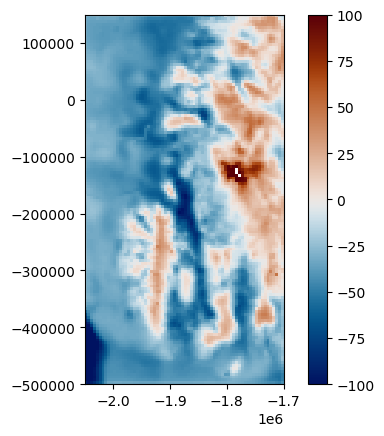

In [24]:
plt.pcolormesh(ds.x, ds.y, target_grids[0], vmin=-100, vmax=100, cmap=cm.vik)
plt.axis('scaled')
plt.colorbar()
plt.show()

In [26]:
tmp = 'result_100795_192.npy'
tmp[:-4].split('_')

['result', '100795', '192']

In [27]:
for entry in os.scandir(Path('iceshelves/abbot/results_gn')):
    if 'result' in entry.name and '._' not in entry.name:
        print(entry.name[:-4].split('_')[-1])

68
140
38
154
95
92
85
62
106
119
151
83
124
35
131
25
9
4
87
13
113
198
36
168
192
165
26
172
174
147
162
153
178
105
6
28
74
114
0
51
107
52
64
44
90
133
179
129
76
189
120
171
91
22
182
19
67
12
50
166
158
181
199
155
24
160
57
175
109
29
177
81
8
125
108
143
122
126
159
27
5
69
117
60
127
110
72
116
173
46
118
61
197
170
65
48
33
71
104
164
54
97
163
130
98
135
39
144
82
88
191
121
45
188
149
190
169
184
21
42
55
43
196
53
187
100
152
195
73
47
112
79
94
56
115
111
148
123
3
142
63
30
157
145
41
146
132
139
86
99
2
180
70
11
20
186
96
78
185
32
18
58
194
14
23
103
141
34
80
1
10
136
101
40
84
137
193
156
49
138
37
31
128
7
134
176
102
59
167
66
16
17
75
93
15
161
77
89
150
183
